In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## MoFA Commodity Price Analysis

### Purpose

This notebook analyses Ministry of Food and Agriculture (MoFA) commodity-price
data to examine how recorded agricultural prices differ by commodity, time,
market type and location.

The analysis supports the Inclusive Farmer Credit Assessment project by
investigating whether a single fixed commodity price is appropriate when
estimating a farmer's expected harvest revenue.

### Data

Source: Ministry of Food and Agriculture (MoFA)

Commodities examined:
- White Maize
- Yellow Maize
- Local Rice – Perfumed
- Local Rice – Non-Perfumed
- Groundnut Red
- Unshelled Groundnut
- Soya Bean

The main analysis focuses on recorded prices from April–October 2025.
Some analyses use a shorter June–October period to improve comparability
across regions.

### Analysis performed

1. Commodity and market-type price comparison
2. Monthly wholesale price movement by commodity
3. Regional wholesale price comparison
4. Average month-to-month price movement

### Key analytical principle

The analysis is descriptive. It shows price differences and movements within
the period covered by the dataset. It does not establish long-term seasonality,
causal relationships or future commodity prices.

### Credit-assessment relevance

The analysis is used to assess whether market/selling-price information should
form part of the proposed farmer credit evidence framework.

The central finding is that recorded prices vary by commodity, product type,
month and location. Therefore, expected farm revenue should not rely on a
single fixed national commodity-price assumption.

### Limitations

- The analysed period is relatively short.
- Market and regional coverage varies across commodities.
- Some commodity-month combinations contain fewer observations than others.
- The available dataset does not clearly document the price unit.
- The findings describe the observed dataset and should not be interpreted as
  long-term price forecasts.

#### AHIES Farmer Sample Analysis

Variables were selected from the AHIES 2022–2023 microdata to describe adult crop farmers in Ghana and identify socioeconomic characteristics relevant to an inclusive agricultural credit assessment framework.

The analysis focuses on farmers aged 18 years and above, excluding farm labourers/workers and livestock-only farmers.

Key areas examined include:


- age
- occupation type/registration
- crop activity and diversification

The analysis is descriptive only. It does not contain farmer-level loan repayment outcomes and therefore cannot be used to validate repayment risk or predict default.

### MOFA commodities visualizations

In [4]:
mofa_four_commodities = pd.read_csv('four_commodity_data.csv') 
mofa_four_commodities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1679 entries, 0 to 1678
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   region      1679 non-null   object 
 1   district    1679 non-null   object 
 2   date        1679 non-null   object 
 3   Market      1617 non-null   object 
 4   source      1679 non-null   object 
 5   commodity   1679 non-null   object 
 6   Price       1679 non-null   float64
 7   market_day  1679 non-null   object 
 8   Year        1679 non-null   int64  
 9   month       1679 non-null   int64  
 10  week        1679 non-null   int64  
 11  Type        1679 non-null   object 
dtypes: float64(1), int64(3), object(8)
memory usage: 157.5+ KB


#### Visualizing Average Price vs. Commodity

In [5]:
mofa_four_commodities['commodity'].value_counts()

commodity
white maize                322
Maize Yellow               318
Rice Local perfumed        279
Groundnut Red              235
Soya Bean                  223
Rice Local non perfumed    200
Unshelled Groundnut        102
Name: count, dtype: int64

In [6]:
# commodity_group = {
#     'white maize': 'Maize',
#     'Maize Yellow': 'Maize',
#     'Rice Local perfumed': 'Rice',
#     'Rice Local non perfumed': 'Rice',
#     'Groundnut Red': 'Groundnut',
#     'Unshelled Groundnut': 'Groundnut',
#     'Soya Bean': 'Soybean'
# }

# mofa_four_commodities['commodity_group'] = mofa_four_commodities['commodity'].map(commodity_group)

In [7]:
mofa_four_commodities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1679 entries, 0 to 1678
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   region           1679 non-null   object 
 1   district         1679 non-null   object 
 2   date             1679 non-null   object 
 3   Market           1617 non-null   object 
 4   source           1679 non-null   object 
 5   commodity        1679 non-null   object 
 6   Price            1679 non-null   float64
 7   market_day       1679 non-null   object 
 8   Year             1679 non-null   int64  
 9   month            1679 non-null   int64  
 10  week             1679 non-null   int64  
 11  Type             1679 non-null   object 
 12  commodity_group  1679 non-null   object 
dtypes: float64(1), int64(3), object(9)
memory usage: 170.7+ KB


In [8]:
mofa_four_commodities.head()

,region,district,date,Market,source,commodity,Price,market_day,Year,month,week,Type,commodity_group
0,Central,Mfantsiman Municipal,16-07-2025,Mankessim,retail,white maize,8.660000,2025-07-16,2025,7,3,retail,Maize
1,Central,Mfantsiman Municipal,16-07-2025,Mankessim,retail,Maize Yellow,9.485000,2025-07-16,2025,7,3,retail,Maize
2,Central,Mfantsiman Municipal,16-07-2025,Mankessim,retail,Rice Local perfumed,20.643333,2025-07-16,2025,7,3,retail,Rice
3,Central,Mfantsiman Municipal,16-07-2025,Mankessim,retail,Rice Local non perfumed,15.110000,2025-07-16,2025,7,3,retail,Rice
4,Central,Mfantsiman Municipal,16-07-2025,Mankessim,retail,Groundnut Red,20.413333,2025-07-16,2025,7,3,retail,Groundnut


In [11]:
mofa_four_commodities['Type'].value_counts()

Type
retail       901
wholesale    778
Name: count, dtype: int64

In [13]:
avg_price = (
    mofa_four_commodities.groupby(['commodity', 'Type'])['Price']
      .mean()
      .reset_index()
)

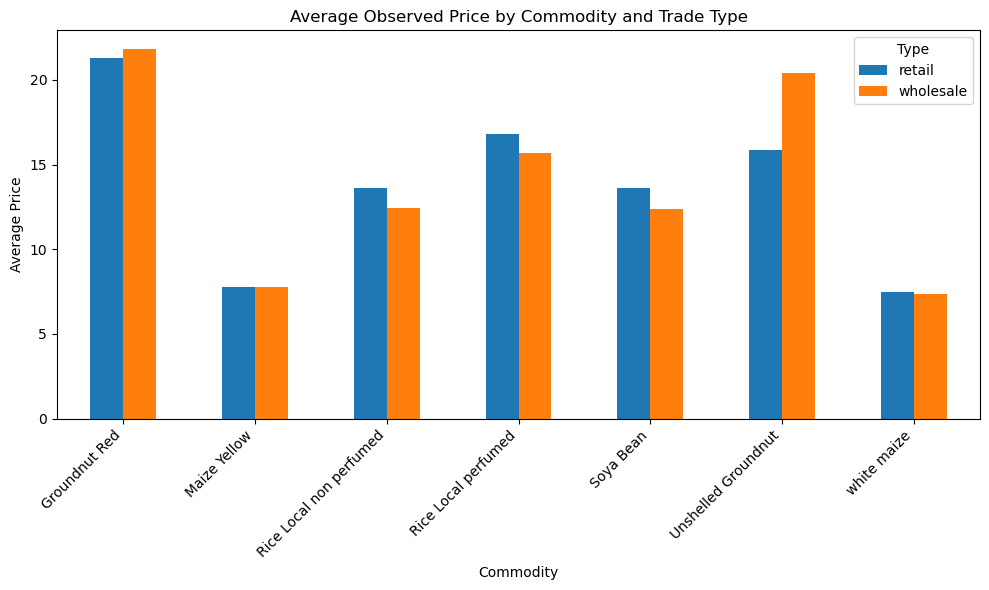

In [18]:

pivot = avg_price.pivot(
    index='commodity',
    columns='Type',
    values='Price'
)

pivot.plot(kind='bar', figsize=(10,6))

plt.title('Average Observed Price by Commodity and Trade Type')
plt.xlabel('Commodity')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
mofa_four_commodities.groupby(['commodity', 'Type'])['Price'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max'
).round(2)

count   mean  median    std    min    max
commodity               Type                                                
Groundnut Red           retail       133  21.29   20.00   7.02  10.85  38.67
                        wholesale    102  21.83   20.33   6.66   4.64  36.00
Maize Yellow            retail       166   7.79    7.41   2.90   3.21  14.19
                        wholesale    152   7.76    6.97   3.16   3.08  15.00
Rice Local non perfumed retail       113  13.63   11.19   4.61   8.04  32.22
                        wholesale     87  12.45   10.71   4.60   5.47  28.00
Rice Local perfumed     retail       148  16.82   14.81   5.14   9.65  37.78
                        wholesale    131  15.67   13.36   5.97   8.14  32.00
Soya Bean               retail       123  13.63   12.50   5.47   5.33  29.44
                        wholesale    100  12.36   12.60   5.08   4.15  27.44
Unshelled Groundnut     retail        54  15.88   14.44  10.32   4.05  75.79
                        wholesale     48  20.39   19.12   9.29   4.37  43.99
white maize             retail       164   7.47    6.95   2.89   2.70  18.96
                        wholesale    158   7.33    6.59   2.91   3.08  14.00

In [ ]:
##### Analysis from the graph Observations()


#### Second visualization (Monthly wholesale price trend)

In [19]:
mofa_four_commodities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1679 entries, 0 to 1678
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   region           1679 non-null   object 
 1   district         1679 non-null   object 
 2   date             1679 non-null   object 
 3   Market           1617 non-null   object 
 4   source           1679 non-null   object 
 5   commodity        1679 non-null   object 
 6   Price            1679 non-null   float64
 7   market_day       1679 non-null   object 
 8   Year             1679 non-null   int64  
 9   month            1679 non-null   int64  
 10  week             1679 non-null   int64  
 11  Type             1679 non-null   object 
 12  commodity_group  1679 non-null   object 
dtypes: float64(1), int64(3), object(9)
memory usage: 170.7+ KB


In [20]:
mofa_four_commodities['Market'].value_counts()

Market
TEMA COMMUNITY ONE MAIN MARKET    155
Goaso                             143
Bibiani                           121
Nana Bosomah                      116
WA MARKET                         110
                                 ... 
Koforidua central                   1
Central market                      1
Koforidua Central Market            1
CENTRAL MARKET                      1
Koforidua central                   1
Name: count, Length: 66, dtype: int64

In [21]:
mofa_four_commodities['date'] = pd.to_datetime(mofa_four_commodities['date'], errors='coerce')

mofa_four_commodities['year_month'] = mofa_four_commodities['date'].dt.to_period('M').dt.to_timestamp()

C:\Users\rauda\AppData\Local\Temp\ipykernel_1068\4125526329.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  mofa_four_commodities['date'] = pd.to_datetime(mofa_four_commodities['date'], errors='coerce')


In [22]:
mofa_four_commodities['date'].min(), mofa_four_commodities['date'].max()

(Timestamp('2025-04-16 00:00:00'), Timestamp('2025-10-31 00:00:00'))

In [23]:
# Calculating the monthly prices

wholesale = mofa_four_commodities[mofa_four_commodities['Type'] == 'wholesale'].copy()

market_month = (
    wholesale
    .groupby(['commodity', 'Market', 'year_month'])['Price']
    .mean()
    .reset_index()
)

In [24]:
monthly_price = (
    market_month
    .groupby(['commodity', 'year_month'])['Price']
    .median()
    .reset_index()
)

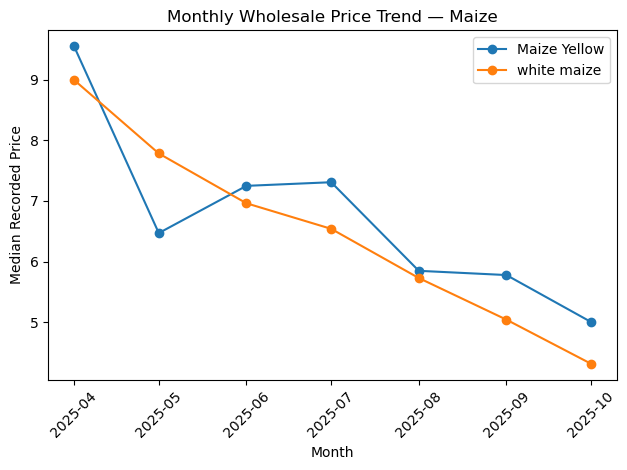

In [25]:
maize = monthly_price[
    monthly_price['commodity'].isin(['white maize', 'Maize Yellow'])
]

for commodity, group in maize.groupby('commodity'):
    plt.plot(
        group['year_month'],
        group['Price'],
        marker='o',
        label=commodity
    )

plt.title('Monthly Wholesale Price Trend — Maize')
plt.xlabel('Month')
plt.ylabel('Median Recorded Price')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

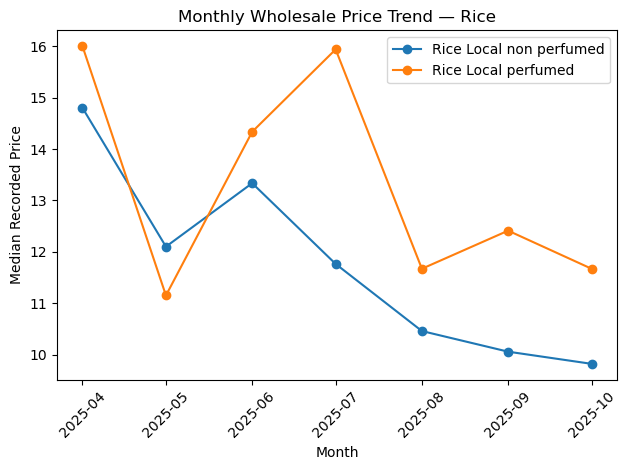

In [29]:
rice = monthly_price[
    monthly_price['commodity'].isin(['Rice Local perfumed', 'Rice Local non perfumed'])
]

for commodity, group in rice.groupby('commodity'):
    plt.plot(
        group['year_month'],
        group['Price'],
        marker='o',
        label=commodity
    )

plt.title('Monthly Wholesale Price Trend — Rice')
plt.xlabel('Month')
plt.ylabel('Median Recorded Price')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

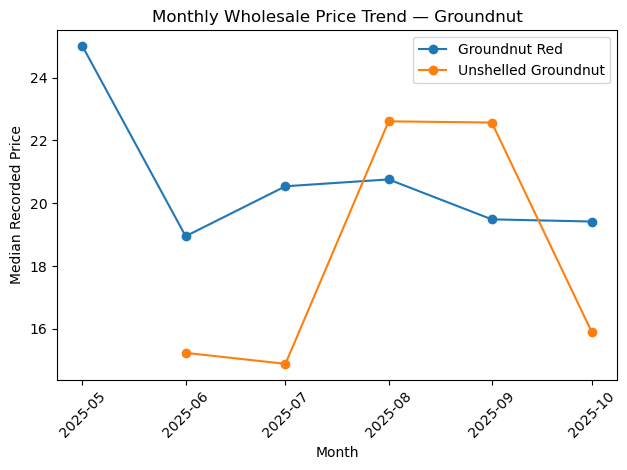

In [30]:
groundnut = monthly_price[
    monthly_price['commodity'].isin(['Groundnut Red', 'Unshelled Groundnut'])
]

for commodity, group in groundnut.groupby('commodity'):
    plt.plot(
        group['year_month'],
        group['Price'],
        marker='o',
        label=commodity
    )

plt.title('Monthly Wholesale Price Trend — Groundnut')
plt.xlabel('Month')
plt.ylabel('Median Recorded Price')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
mofa_four_commodities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1679 entries, 0 to 1678
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   region           1679 non-null   object        
 1   district         1679 non-null   object        
 2   date             1679 non-null   datetime64[ns]
 3   Market           1617 non-null   object        
 4   source           1679 non-null   object        
 5   commodity        1679 non-null   object        
 6   Price            1679 non-null   float64       
 7   market_day       1679 non-null   object        
 8   Year             1679 non-null   int64         
 9   month            1679 non-null   int64         
 10  week             1679 non-null   int64         
 11  Type             1679 non-null   object        
 12  commodity_group  1679 non-null   object        
 13  year_month       1679 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(

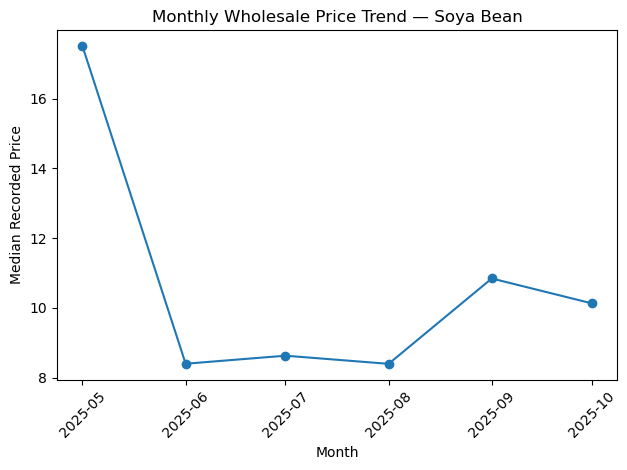

In [31]:
soya = monthly_price[
    monthly_price['commodity'] == 'Soya Bean'
]

plt.plot(
    soya['year_month'],
    soya['Price'],
    marker='o'
)

plt.title('Monthly Wholesale Price Trend — Soya Bean')
plt.xlabel('Month')
plt.ylabel('Median Recorded Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
mofa_four_commodities['commodity'].value_counts()

commodity
white maize                322
Maize Yellow               318
Rice Local perfumed        279
Groundnut Red              235
Soya Bean                  223
Rice Local non perfumed    200
Unshelled Groundnut        102
Name: count, dtype: int64

#### Third visualization

In [35]:
wholesale = mofa_four_commodities[
    mofa_four_commodities['Type'] == 'wholesale'
].copy()

In [37]:
region_counts = (
    wholesale
    .groupby(['commodity', 'region'])
    .size()
    .reset_index(name='n')
)

# print(
#     region_counts
#     .sort_values(['commodity', 'n'], ascending=[True, False])
#     .to_string(index=False)
# )

In [38]:
maize_regions = [
    'Bono East',
    'Greater Accra',
    'Western North',
    'Ahafo',
    'Upper West',
    'Bono',
    'Upper East'
]

rice_regions = [
    'Bono East',
    'Western North',
    'Bono',
    'Upper West'
]

groundnut_regions = [
    'Bono East',
    'Western North'
]

soya_regions = [
    'Bono East',
    'Western North',
    'Greater Accra',
    'Upper West',
    'Upper East'
]

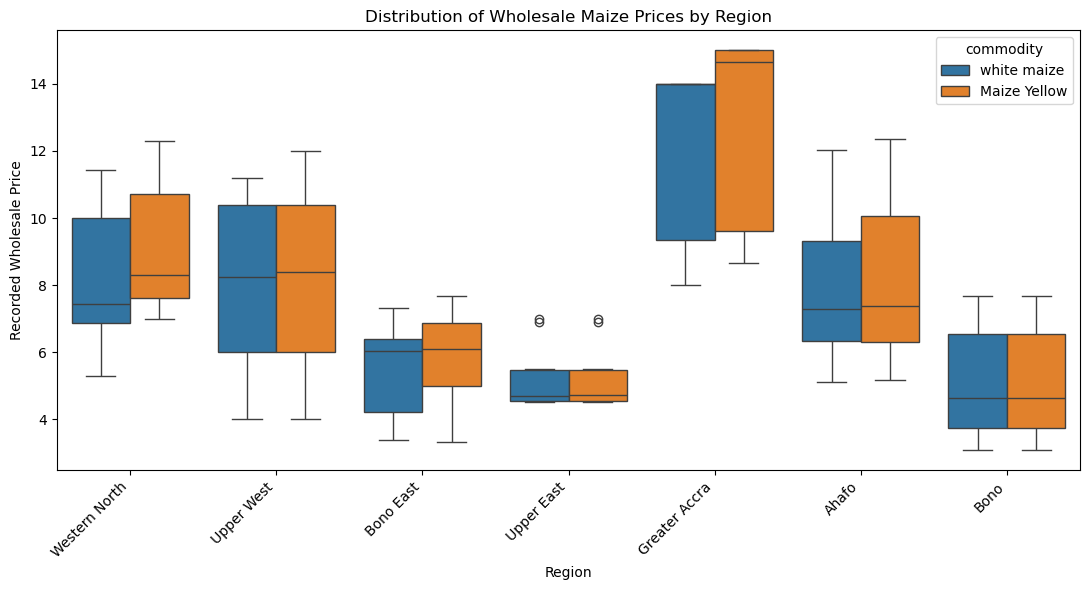

In [41]:
maize_region = wholesale[
    (wholesale['commodity'].isin([
        'white maize',
        'Maize Yellow'
    ])) &
    (wholesale['region'].isin(maize_regions))
]

plt.figure(figsize=(11, 6))

sns.boxplot(
    data=maize_region,
    x='region',
    y='Price',
    hue='commodity'
)

plt.title('Distribution of Wholesale Maize Prices by Region')
plt.xlabel('Region')
plt.ylabel('Recorded Wholesale Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

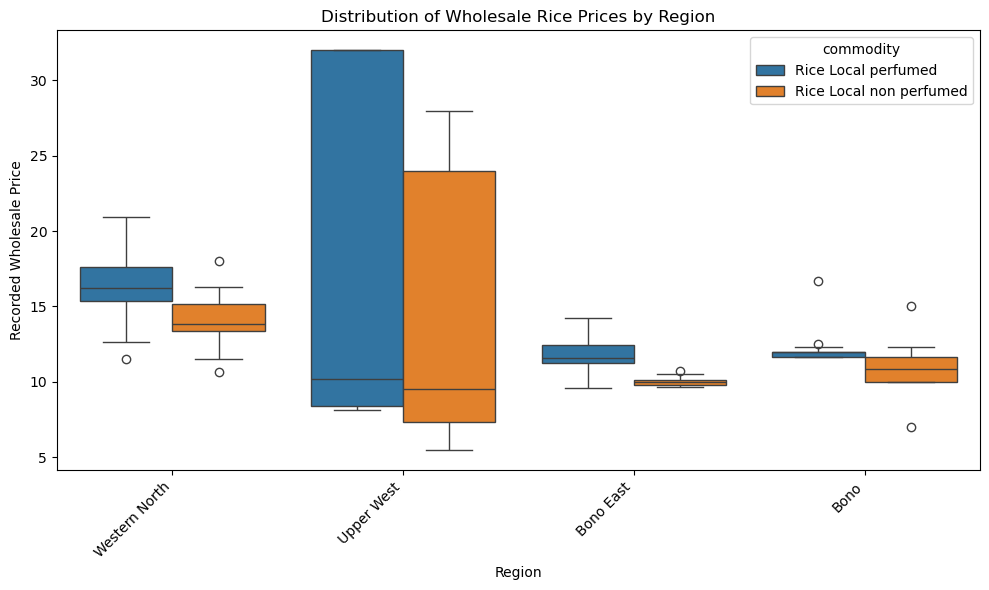

In [42]:
rice_region = wholesale[
    (wholesale['commodity'].isin([
        'Rice Local perfumed',
        'Rice Local non perfumed'
    ])) &
    (wholesale['region'].isin(rice_regions))
]

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=rice_region,
    x='region',
    y='Price',
    hue='commodity'
)

plt.title('Distribution of Wholesale Rice Prices by Region')
plt.xlabel('Region')
plt.ylabel('Recorded Wholesale Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

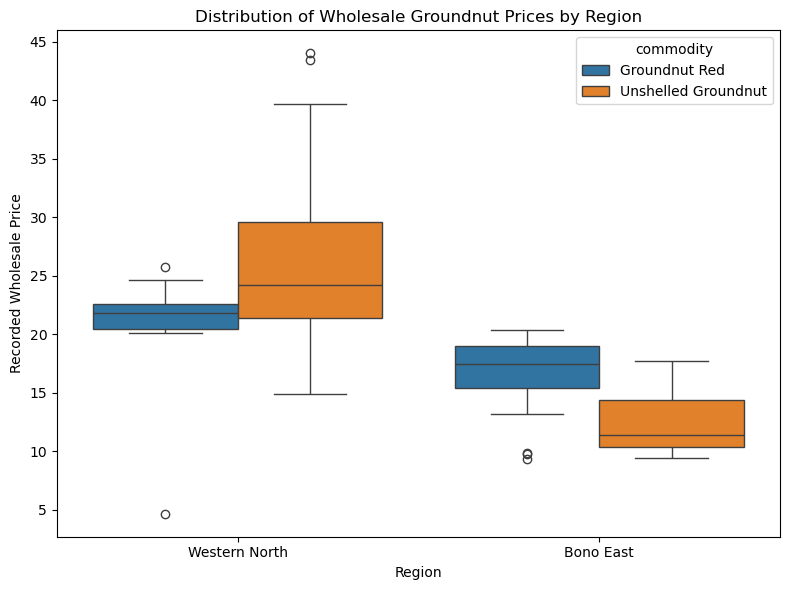

In [43]:
groundnut_region = wholesale[
    (wholesale['commodity'].isin([
        'Groundnut Red',
        'Unshelled Groundnut'
    ])) &
    (wholesale['region'].isin(groundnut_regions))
]

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=groundnut_region,
    x='region',
    y='Price',
    hue='commodity'
)

plt.title('Distribution of Wholesale Groundnut Prices by Region')
plt.xlabel('Region')
plt.ylabel('Recorded Wholesale Price')
plt.tight_layout()
plt.show()

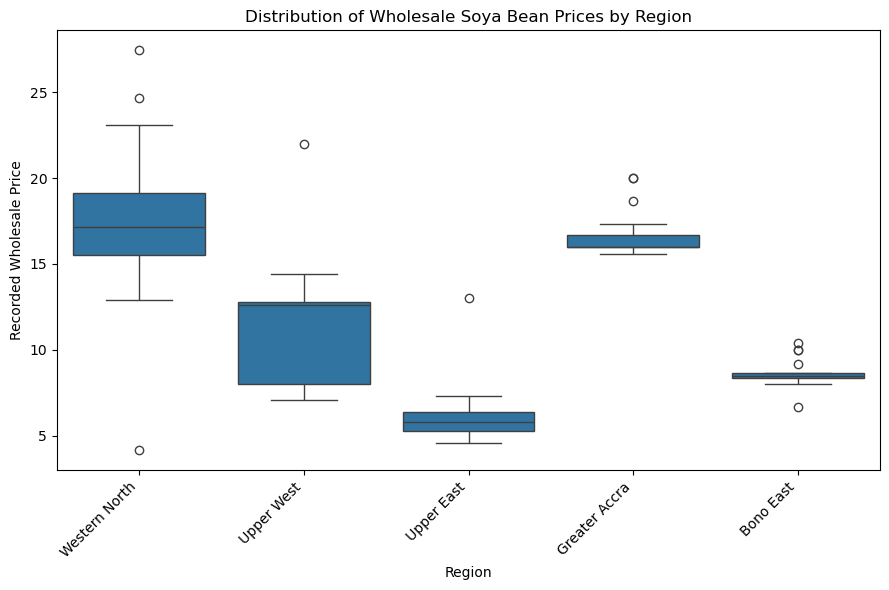

In [44]:
soya_region = wholesale[
    (wholesale['commodity'] == 'Soya Bean') &
    (wholesale['region'].isin(soya_regions))
]

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=soya_region,
    x='region',
    y='Price'
)

plt.title('Distribution of Wholesale Soya Bean Prices by Region')
plt.xlabel('Region')
plt.ylabel('Recorded Wholesale Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [45]:
pd.crosstab(
    wholesale_region['region'],
    wholesale_region['year_month']
)

NameError: name 'wholesale_region' is not defined

In [50]:
print("maize")
pd.crosstab(
    maize_region['region'],
    maize_region['year_month']
)

maize


year_month,2025-04-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01
region,,,,,,
Ahafo,0,6,9,8,8,8
Bono,0,4,8,6,6,6
Bono East,0,10,14,20,16,9
Greater Accra,2,8,14,6,8,8
Upper East,0,8,4,8,2,0
Upper West,0,6,6,6,8,10
Western North,0,6,8,8,8,10


In [51]:
print("rice")

pd.crosstab(
    rice_region['region'],
    rice_region['year_month']
)

rice


year_month,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01
region,,,,,
Bono,4,8,6,6,6
Bono East,7,9,15,10,7
Upper West,6,6,4,5,8
Western North,4,8,8,8,10


In [52]:
print("groundnut")

pd.crosstab(
    groundnut_region['region'],
    groundnut_region['year_month']
)

groundnut


year_month,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01
region,,,,,
Bono East,5,10,10,7,4
Western North,6,10,8,8,9


In [54]:
print("soya bean")

pd.crosstab(
    soya_region['region'],
    soya_region['year_month']
)

soya bean


year_month,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01
region,,,,,
Bono East,2,6,5,6,5
Greater Accra,3,4,3,4,4
Upper East,4,2,3,1,0
Upper West,3,3,0,4,4
Western North,3,5,4,4,5


#### Fourth visualization

In [55]:
monthly_price = monthly_price.sort_values(
    ['commodity', 'year_month']
)

monthly_price['monthly_change_pct'] = (
    monthly_price
    .groupby('commodity')['Price']
    .pct_change() * 100
)

In [56]:
monthly_price['absolute_change_pct'] = (
    monthly_price['monthly_change_pct'].abs()
)

In [57]:
avg_monthly_change = (
    monthly_price
    .groupby('commodity')['absolute_change_pct']
    .mean()
    .reset_index()
    .sort_values('absolute_change_pct', ascending=False)
)

avg_monthly_change

,commodity,absolute_change_pct
5,Unshelled Groundnut,20.961131
4,Soya Bean,18.628712
3,Rice Local perfumed,18.194455
1,Maize Yellow,13.307032
6,white maize,11.507430
2,Rice Local non perfumed,9.587278
0,Groundnut Red,8.027670


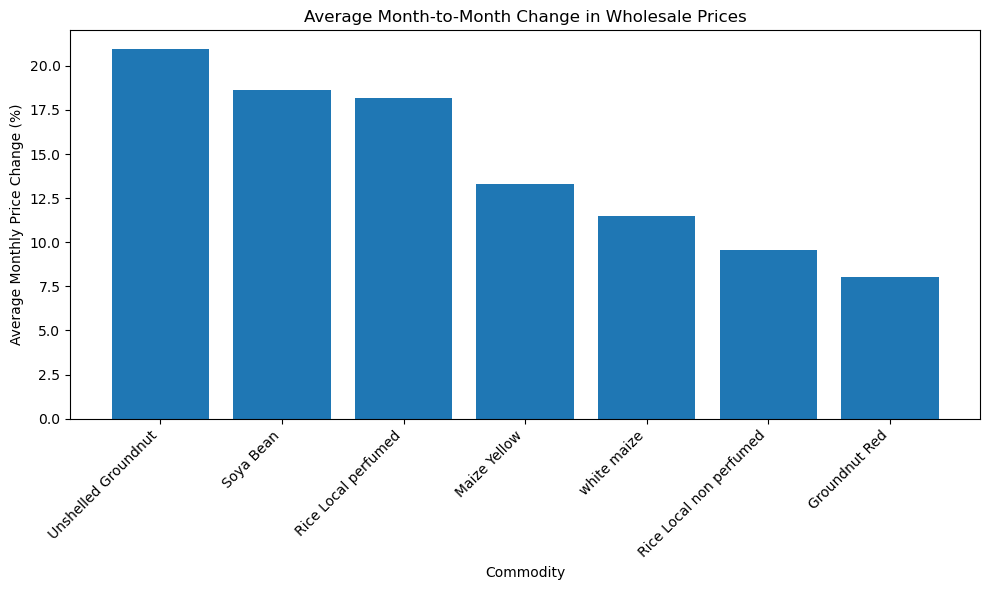

In [58]:
plt.figure(figsize=(10,6))

plt.bar(
    avg_monthly_change['commodity'],
    avg_monthly_change['absolute_change_pct']
)

plt.title('Average Month-to-Month Change in Wholesale Prices')
plt.xlabel('Commodity')
plt.ylabel('Average Monthly Price Change (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

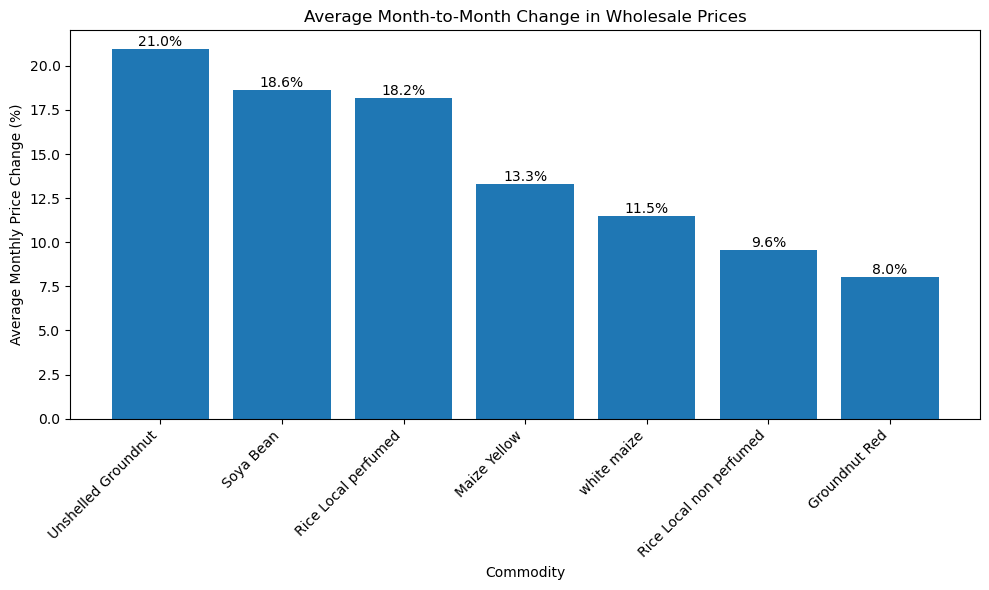

In [64]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    avg_monthly_change['commodity'],
    avg_monthly_change['absolute_change_pct']
)

plt.title('Average Month-to-Month Change in Wholesale Prices')
plt.xlabel('Commodity')
plt.ylabel('Average Monthly Price Change (%)')
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [63]:
monthly_price = monthly_price.sort_values(
    ['commodity', 'year_month']
).copy()

# Create a numeric month index
monthly_price['month_number'] = (
    monthly_price['year_month'].dt.year * 12 +
    monthly_price['year_month'].dt.month
)

# Check how many months passed since the previous observation
monthly_price['month_gap'] = (
    monthly_price
    .groupby('commodity')['month_number']
    .diff()
)

# Calculate percentage change
monthly_price['monthly_change_pct'] = (
    monthly_price
    .groupby('commodity')['Price']
    .pct_change() * 100
)

# Keep ONLY true month-to-month changes
monthly_changes = monthly_price[
    monthly_price['month_gap'] == 1
].copy()

# Ignore direction: we only want size of movement
monthly_changes['absolute_change_pct'] = (
    monthly_changes['monthly_change_pct'].abs()
)

# Average movement for each commodity
avg_monthly_change = (
    monthly_changes
    .groupby('commodity')['absolute_change_pct']
    .mean()
    .reset_index()
    .sort_values('absolute_change_pct', ascending=False)
)

avg_monthly_change

,commodity,absolute_change_pct
5,Unshelled Groundnut,20.961131
4,Soya Bean,18.628712
3,Rice Local perfumed,18.194455
1,Maize Yellow,13.307032
6,white maize,11.507430
2,Rice Local non perfumed,9.587278
0,Groundnut Red,8.027670


### Annual Household Income and Expenditure Survey (AHIES)

In [4]:
ahies = pd.read_csv('farmer_data_ahies.csv')
ahies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1926 entries, 0 to 1925
Data columns (total 15 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   hhid                                 1926 non-null   int64 
 1   quarter                              1926 non-null   object
 2   cluster                              1926 non-null   int64 
 3   HholdID                              1926 non-null   int64 
 4   personid                             1926 non-null   int64 
 5   s1aq1_gender                         1926 non-null   object
 6   s1aq2_ role_in_household             1926 non-null   object
 7   s2aq3_highest_level_of_education     1923 non-null   object
 8   s4aq40a_occupation                   1926 non-null   object
 9   s4aq42_occupation_type_registration  1877 non-null   object
 10  s4aq44_occupation_place              1918 non-null   object
 11  s1aq4y_age                           1926 n

In [5]:
ahies['s4aq42_occupation_type_registration'].value_counts(dropna=False)

s4aq42_occupation_type_registration
Private Informal    1873
NaN                   49
Private Formal         3
Local NGO/CSO          1
Name: count, dtype: int64

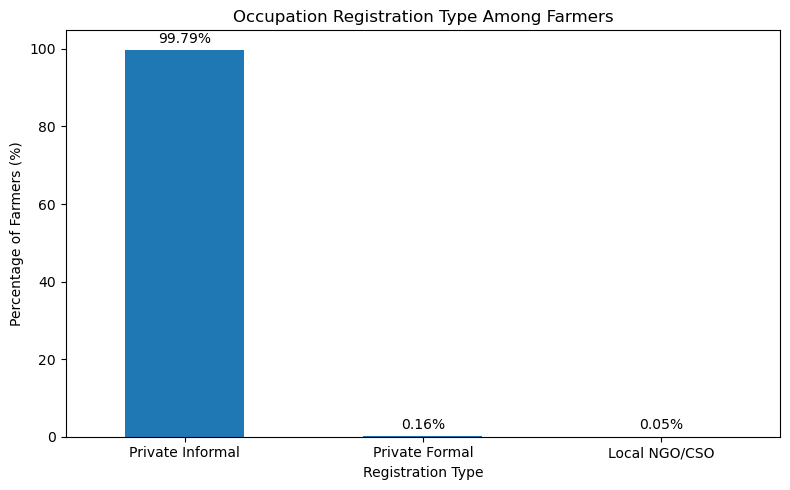

In [6]:
import matplotlib.pyplot as plt

# Remove missing values
registration_counts = (
    ahies['s4aq42_occupation_type_registration']
    .dropna()
    .value_counts()
)

# Convert counts to percentages
registration_percent = (
    registration_counts / registration_counts.sum() * 100
)

# Plot
ax = registration_percent.plot(kind='bar', figsize=(8, 5))

plt.title('Occupation Registration Type Among Farmers')
plt.xlabel('Registration Type')
plt.ylabel('Percentage of Farmers (%)')
plt.xticks(rotation=0)

# Add percentage labels on the bars
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{value:.2f}%' for value in registration_percent],
        padding=3
    )

plt.tight_layout()
plt.show()

##### Age distribution among farmers

In [7]:
ahies['s1aq4y_age'].describe()

count    1926.000000
mean       42.473520
std        15.512243
min        18.000000
25%        30.000000
50%        42.000000
75%        52.000000
max        99.000000
Name: s1aq4y_age, dtype: float64

In [8]:
ahies['s1bq5a_region of stay'].isna().sum()

1299

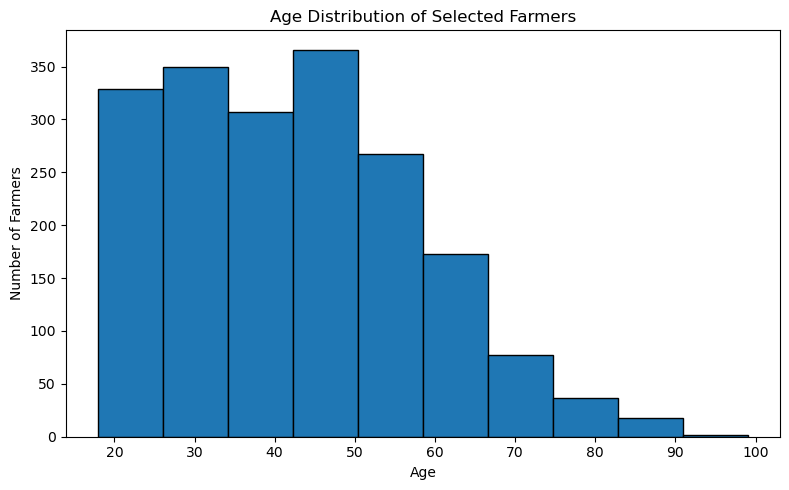

In [9]:
plt.figure(figsize=(8,5))

plt.hist(
    ahies['s1aq4y_age'],
    bins=10,
    edgecolor='black'
)

plt.title('Age Distribution of Selected Farmers')
plt.xlabel('Age')
plt.ylabel('Number of Farmers')
plt.tight_layout()
plt.show()

#### Farmer types

In [10]:
ahies['s4aq40a_occupation'].value_counts()

s4aq40a_occupation
A FARMER WHO GROW CEREAL CROPS                                                162
MIXED CROP FARMER MAIZE, YAM, BEANS, SOYA BEANS, BAMBARA BEANS, MILLET         78
MIXED CROP FARMER (MAIZE, MILLETS, BEANS,BAMBARA BEANS AND GROUNDNUTS          48
MIXED CROP FARMER (MAIZE,MILLETS, YAM,GROUNDNUTS, BAMBARA BEANS AND BEANS)     43
A FARMER WHO CULTIVATE CEREAL CROPS                                            26
                                                                             ... 
A FARMER WHO CULTIVATE GROUNDNUT, MAIZE, MALLET AND BEANS                       1
A FARMER WHO GROW RICE, MILLET AND MAIZE                                        1
A FARMER WHO CULTIVATE MILLET,MAIZE, OKRO AND RICE                              1
A FARMER WHO CULTIVATE MILLET, MAIZE, BAMBARA BEANS AND GROUNDNUT               1
MIXED CROP FARMER ( MAIZE, GROUNDNUT, SOYA BEANS, )                             1
Name: count, Length: 921, dtype: int64

In [11]:
ahies['s4aq40a_occupation'].nunique()

921

In [12]:
occupation = (
    ahies['s4aq40a_occupation']
    .fillna('')
    .str.upper()
    .str.strip()
)

In [13]:
ahies['maize'] = occupation.str.contains(r'\bMAIZE\b', regex=True)

ahies['rice'] = occupation.str.contains(r'\bRICE\b', regex=True)

ahies['soya'] = occupation.str.contains(
    r'\bSOYA\b|\bSOYBEAN\b|\bSOY BEAN\b',
    regex=True
)

ahies['groundnut'] = occupation.str.contains(
    r'\bGROUNDNUT\b|\bGROUNDNUTS\b',
    regex=True
)

In [14]:
crop_cols = ['maize', 'rice', 'soya', 'groundnut']

crop_counts = ahies[crop_cols].sum()

crop_summary = crop_counts.to_frame('count')

crop_summary['percentage'] = (
    crop_summary['count'] / len(ahies) * 100
)

crop_summary = crop_summary.sort_values(
    'percentage',
    ascending=False
)

crop_summary

,count,percentage
maize,1423,73.883697
groundnut,1038,53.894081
rice,268,13.914849
soya,132,6.853583


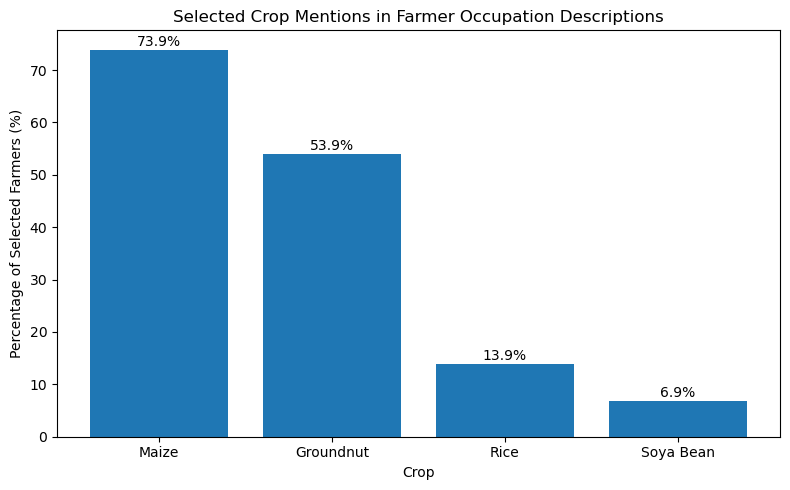

In [15]:
import matplotlib.pyplot as plt

labels = {
    'maize': 'Maize',
    'rice': 'Rice',
    'soya': 'Soya Bean',
    'groundnut': 'Groundnut'
}

plot_data = crop_summary.copy()
plot_data.index = plot_data.index.map(labels)

plt.figure(figsize=(8,5))

bars = plt.bar(
    plot_data.index,
    plot_data['percentage']
)

plt.title('Selected Crop Mentions in Farmer Occupation Descriptions')
plt.xlabel('Crop')
plt.ylabel('Percentage of Selected Farmers (%)')

for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f'{height:.1f}%',
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center'
    )

plt.tight_layout()
plt.show()